# Session 3 – DBSCAN (Density-Based Clustering)

## 1. DBSCAN on the Mall Customers Dataset
Features used: **Annual Income (k$)** and **Spending Score (1-100)**.
Both features are standardised first because DBSCAN's `eps` is a distance threshold, so features must be on the same scale.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler

# Load locally if available, otherwise from a public mirror of the Kaggle dataset
LOCAL = "Mall_Customers.csv"
URL = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(LOCAL if os.path.exists(LOCAL) else URL)

print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X_raw = df[features].values
X = StandardScaler().fit_transform(X_raw)

EPS, MIN_SAMPLES = 0.4, 8
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))

print(f"DBSCAN(eps={EPS}, min_samples={MIN_SAMPLES})")
print("Number of clusters found :", n_clusters)
print("Number of noise points   :", n_noise)
print("\nPoints per cluster (-1 = noise):")
print(pd.Series(labels).value_counts().sort_index())

DBSCAN(eps=0.4, min_samples=8)
Number of clusters found : 5
Number of noise points   : 25

Points per cluster (-1 = noise):
-1    25
 0    14
 1    12
 2    95
 3    30
 4    24
Name: count, dtype: int64


## 2. Visualising the DBSCAN Clusters
Each cluster gets its own colour; noise points (label `-1`) are shown in **black**.

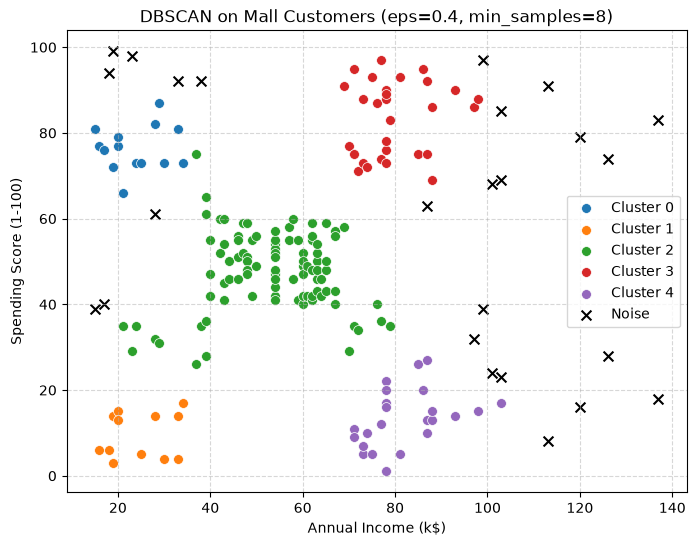

In [3]:
def plot_dbscan(X_plot, labels, ax=None, title="DBSCAN Clustering"):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))
    unique = sorted(set(labels))
    cluster_ids = [l for l in unique if l != -1]
    cmap = plt.get_cmap("tab10")
    for i, lbl in enumerate(cluster_ids):
        mask = labels == lbl
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1], s=50, color=cmap(i % 10),
                   edgecolor="white", linewidth=0.5, label=f"Cluster {lbl}")
    if -1 in unique:
        mask = labels == -1
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1], s=50, c="black", marker="x", label="Noise")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    return ax


ax = plot_dbscan(X_raw, labels, title=f"DBSCAN on Mall Customers (eps={EPS}, min_samples={MIN_SAMPLES})")
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")
plt.show()

**Observation:** DBSCAN finds the 5 classic mall segments – *average income / average spenders* (the big central group),
*high income / high spenders*, *high income / low spenders*, *low income / high spenders* and *low income / low spenders*.
Customers at the extreme edges (e.g. very high income) are not dense enough and are flagged as noise.

## 3. Effect of `eps` and `min_samples`

In [4]:
results = []
for eps in [0.3, 0.4, 0.5]:
    for ms in [5, 8, 10]:
        lbl = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        results.append({
            "eps": eps,
            "min_samples": ms,
            "clusters": len(set(lbl)) - (1 if -1 in lbl else 0),
            "noise_points": int(np.sum(lbl == -1)),
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 eps  min_samples  clusters  noise_points
 0.3            5         7            35
 0.3            8         5            72
 0.3           10         4            88
 0.4            5         4            15
 0.4            8         5            25
 0.4           10         4            51
 0.5            5         2             8
 0.5            8         2            15
 0.5           10         4            21


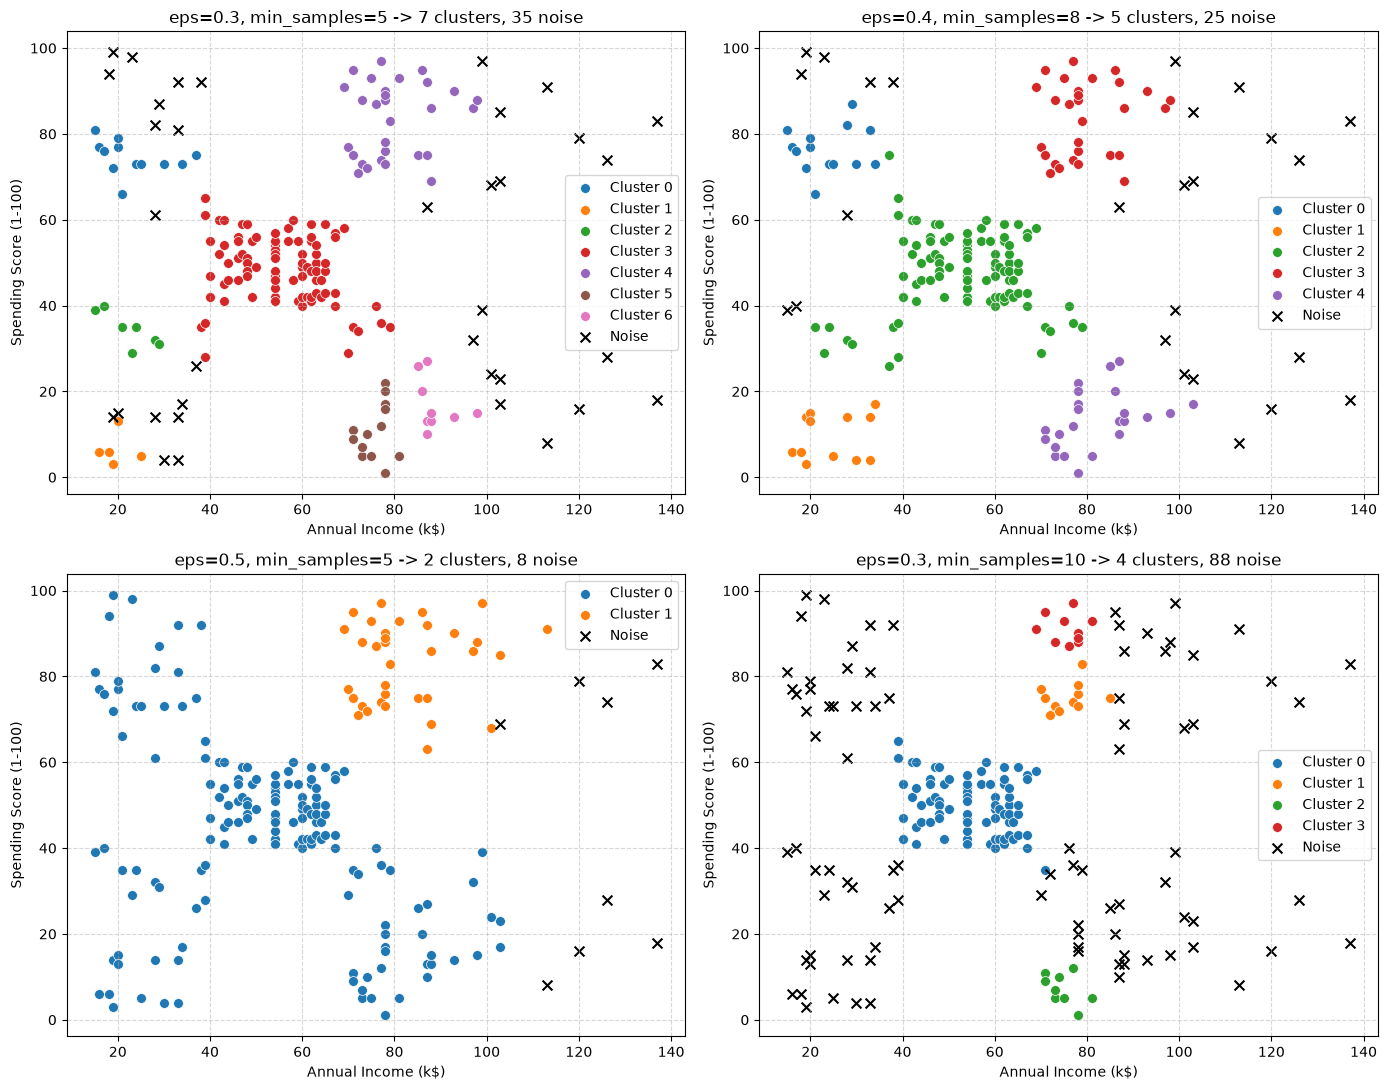

In [5]:
# Visual comparison of a few settings
settings = [(0.3, 5), (0.4, 8), (0.5, 5), (0.3, 10)]
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (eps, ms) in zip(axes.ravel(), settings):
    lbl = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
    k = len(set(lbl)) - (1 if -1 in lbl else 0)
    plot_dbscan(X_raw, lbl, ax=ax,
                title=f"eps={eps}, min_samples={ms} -> {k} clusters, {np.sum(lbl == -1)} noise")
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()

### Summary
- **Increasing `eps`** (0.3 → 0.5) makes each neighbourhood larger, so nearby groups merge: noise drops sharply, but with eps=0.5 the five segments collapse into just **2 big clusters**.
- **Increasing `min_samples`** (5 → 10) makes the density requirement stricter, so more customers are labelled **noise** (e.g. at eps=0.3 noise grows from 35 → 88) and small groups disappear.
- A small eps with a small min_samples splits the data into many tiny clusters, while a large eps over-merges.
- For this dataset, **eps ≈ 0.4 with min_samples = 8** gives the best balance: 5 meaningful customer segments with only ~25 outliers.

## 4. DBSCAN vs K-Means (same features, same number of clusters)
K-Means is run with `k` = the number of clusters DBSCAN found in Task 1.

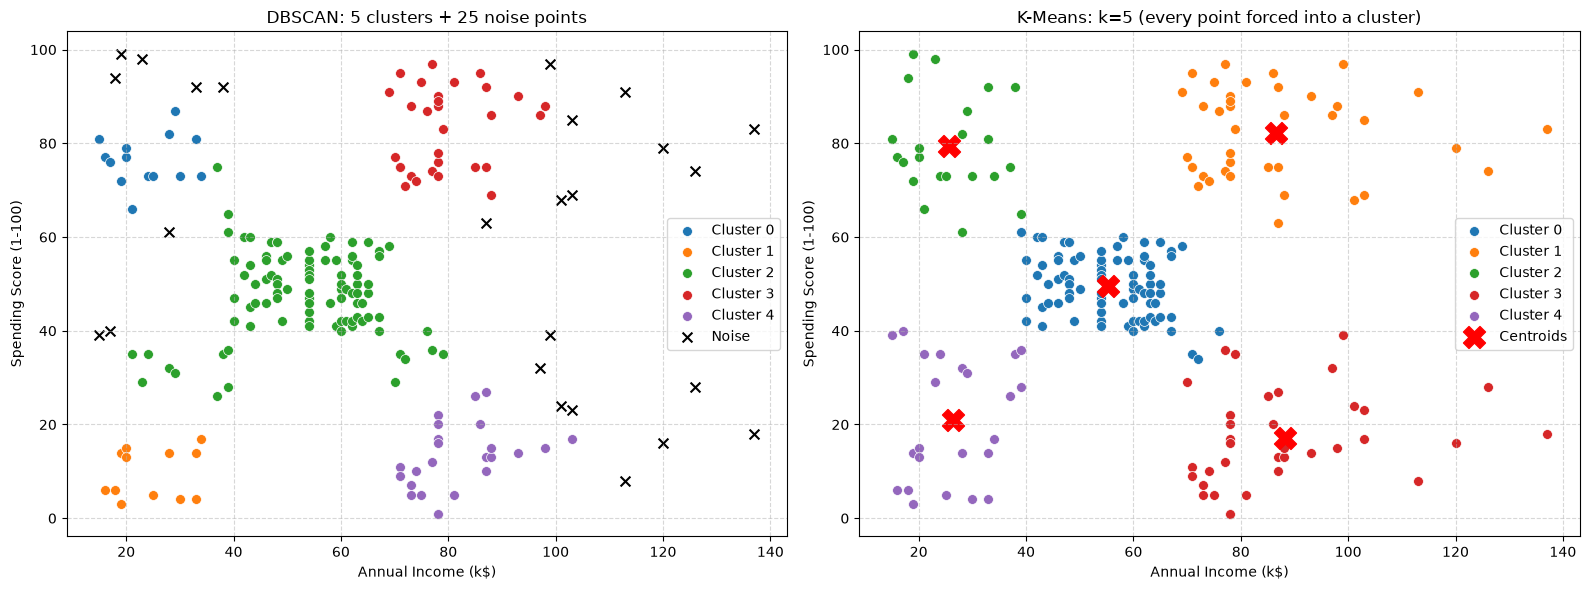

In [6]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_dbscan(X_raw, labels, ax=axes[0],
            title=f"DBSCAN: {n_clusters} clusters + {n_noise} noise points")

cmap = plt.get_cmap("tab10")
for c in range(n_clusters):
    mask = km_labels == c
    axes[1].scatter(X_raw[mask, 0], X_raw[mask, 1], s=50, color=cmap(c),
                    edgecolor="white", linewidth=0.5, label=f"Cluster {c}")
centers = StandardScaler().fit(X_raw).inverse_transform(kmeans.cluster_centers_)
axes[1].scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=250, label="Centroids")
axes[1].set_title(f"K-Means: k={n_clusters} (every point forced into a cluster)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()

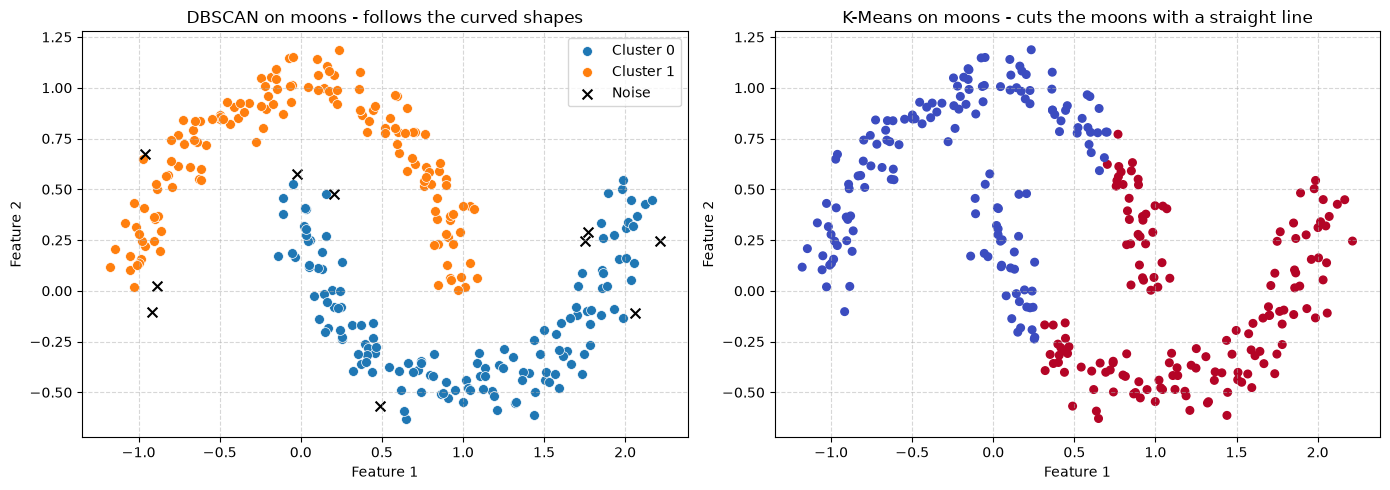

In [7]:
# Bonus: the same comparison on oddly-shaped (moon) clusters
from sklearn.datasets import make_moons

Xm, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
db_m = DBSCAN(eps=0.15, min_samples=8).fit_predict(Xm)
km_m = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(Xm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_dbscan(Xm, db_m, ax=axes[0], title="DBSCAN on moons - follows the curved shapes")
axes[1].scatter(Xm[:, 0], Xm[:, 1], c=km_m, cmap="coolwarm", s=30)
axes[1].set_title("K-Means on moons - cuts the moons with a straight line")
axes[1].grid(True, linestyle="--", alpha=0.5)
for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
plt.tight_layout()
plt.show()

### Which method handles outliers / odd shapes better?
- **Outliers:** DBSCAN is clearly better. It labels sparse, extreme customers as **noise (black ×)**, whereas K-Means must place *every* customer in a cluster,
  so outliers drag the centroids and blur segment boundaries.
- **Cluster shape:** K-Means assumes round (spherical), similarly sized clusters split by straight boundaries. DBSCAN grows clusters by density,
  so it can follow **arbitrary shapes** – as the moons example shows, K-Means cuts each moon in half while DBSCAN recovers both moons correctly.
- **Trade-off:** On the Mall data both methods find similar 5 segments because those groups are roughly round; K-Means is simpler and needs only `k`,
  while DBSCAN needs careful tuning of `eps` and `min_samples` but does not require `k` in advance.

## 5. DBSCAN on Non-Spherical Clusters (make_moons) – Finding Noise Points
We generate two interleaving half-moons and add a few random scattered points as deliberate outliers.

In [8]:
from sklearn.datasets import make_moons

X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

# Add 8 random outliers scattered around the moons
rng = np.random.default_rng(7)
outliers = rng.uniform(low=[-1.5, -1.0], high=[2.5, 1.5], size=(8, 2))
X_all = np.vstack([X_moons, outliers])

db = DBSCAN(eps=0.15, min_samples=8)
moon_labels = db.fit_predict(X_all)

n_clusters_m = len(set(moon_labels)) - (1 if -1 in moon_labels else 0)
noise_idx = np.where(moon_labels == -1)[0]

print("Number of clusters found:", n_clusters_m)
print("Number of noise points  :", len(noise_idx))
print("Indices of noise points :", noise_idx.tolist())
print("\nCoordinates of noise points:")
print(pd.DataFrame(X_all[noise_idx], index=noise_idx, columns=["x", "y"]).round(3))

Number of clusters found: 2
Number of noise points  : 15
Indices of noise points : [18, 75, 97, 166, 178, 191, 193, 220, 223, 240, 300, 303, 305, 306, 307]

Coordinates of noise points:
         x      y
18  -0.885  0.022
75   1.769  0.291
97  -0.917 -0.103
166  1.750  0.244
178  2.215  0.245
191 -0.022  0.576
193  0.489 -0.568
220 -0.961  0.672
223  0.205  0.479
240  2.059 -0.110
300  1.000  1.243
303 -1.479  1.053
305 -0.288 -0.304
306 -0.481  0.113
307  0.518  0.384


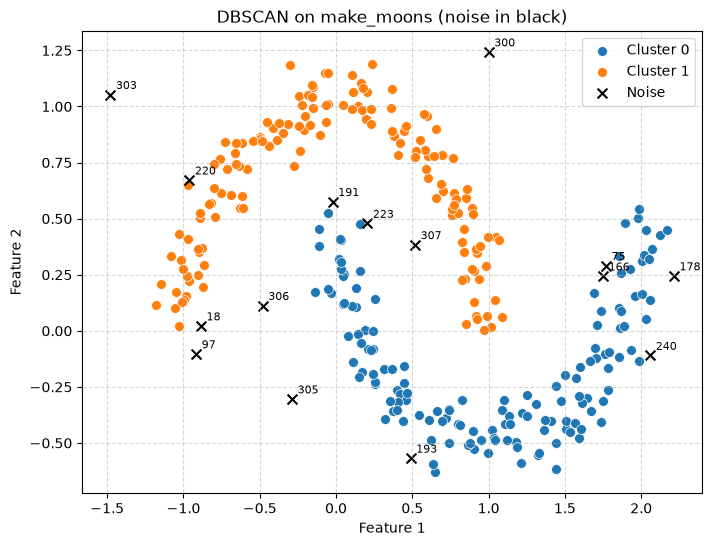

In [9]:
ax = plot_dbscan(X_all, moon_labels, title="DBSCAN on make_moons (noise in black)")
for i in noise_idx:
    ax.annotate(str(i), X_all[i], xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

**Observation:** DBSCAN correctly recovers the **two crescent-shaped clusters** (which K-Means cannot do) and flags 15 points as noise:
indices **≥ 300** are injected outliers (5 of the 8 – the other 3 happened to land inside a dense moon region, so DBSCAN treats them as normal members),
and the remaining indices (< 300) are naturally isolated moon points at the sparse tips/edges of the crescents.